In [ ]:
!pip install pandas

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import glob
import os

print("Libraries loaded successfully")

Libraries loaded successfully


In [ ]:
# Path to the folder containing the 12 CSV files
DATA_DIR = '/content/drive/MyDrive/Data analytics/PRSA_Data_20130301-20170228'

# Find all CSV files matching the pattern
files = sorted(glob.glob(f'{DATA_DIR}/PRSA_Data_*.csv'))

print(f"Found {len(files)} files:")
for f in files:
    print(f"  {os.path.basename(f)}")

Found 12 files:
  PRSA_Data_Aotizhongxin_20130301-20170228.csv
  PRSA_Data_Changping_20130301-20170228.csv
  PRSA_Data_Dingling_20130301-20170228.csv
  PRSA_Data_Dongsi_20130301-20170228.csv
  PRSA_Data_Guanyuan_20130301-20170228.csv
  PRSA_Data_Gucheng_20130301-20170228.csv
  PRSA_Data_Huairou_20130301-20170228.csv
  PRSA_Data_Nongzhanguan_20130301-20170228.csv
  PRSA_Data_Shunyi_20130301-20170228.csv
  PRSA_Data_Tiantan_20130301-20170228.csv
  PRSA_Data_Wanliu_20130301-20170228.csv
  PRSA_Data_Wanshouxigong_20130301-20170228.csv


In [ ]:
dfs = []  # empty list to collect each station's DataFrame

for filepath in files:
    # Extract station name from filename
    filename = os.path.basename(filepath)
    station_name = filename.replace('PRSA_Data_', '') \
                           .replace('_20130301-20170228.csv', '')

    # Load the CSV
    df = pd.read_csv(filepath)

    # Add station column so rows are identifiable after combining
    df['station'] = station_name

    dfs.append(df)
    print(f"Loaded: {station_name} — {df.shape[0]:,} rows")

Loaded: Aotizhongxin — 35,064 rows
Loaded: Changping — 35,064 rows
Loaded: Dingling — 35,064 rows
Loaded: Dongsi — 35,064 rows
Loaded: Guanyuan — 35,064 rows
Loaded: Gucheng — 35,064 rows
Loaded: Huairou — 35,064 rows
Loaded: Nongzhanguan — 35,064 rows
Loaded: Shunyi — 35,064 rows
Loaded: Tiantan — 35,064 rows
Loaded: Wanliu — 35,064 rows
Loaded: Wanshouxigong — 35,064 rows


In [ ]:
combined = pd.concat(dfs, ignore_index=True)

print(f"Combined shape: {combined.shape}")
print(f"Rows : {combined.shape[0]:,}")
print(f"Columns: {combined.shape[1]}")
print(f"Stations: {combined['station'].nunique()}")

Combined shape: (420768, 18)
Rows : 420,768
Columns: 18
Stations: 12


In [ ]:
combined.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


In [ ]:
combined.dtypes

,0
No,int64
year,int64
month,int64
day,int64
hour,int64
PM2.5,float64
PM10,float64
SO2,float64
NO2,float64
CO,float64


# **Task 02**

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

identify  missing columns

In [ ]:
print("Missing values per column:")
print(combined.isnull().sum())
print(f"Total missing cells: {combined.isnull().sum().sum():,}")

Missing values per column:
No             0
year           0
month          0
day            0
hour           0
PM2.5       8739
PM10        6449
SO2         9021
NO2        12116
CO         20701
O3         13277
TEMP         398
PRES         393
DEWP         403
RAIN         390
wd          1822
WSPM         318
station        0
dtype: int64
Total missing cells: 74,027


In [ ]:
numeric_cols = ['PM2.5', 'PM10', 'SO2', 'NO2',
               'CO', 'O3', 'TEMP', 'PRES',
               'DEWP', 'RAIN', 'WSPM']

for col in numeric_cols:
    combined[col] = combined.groupby('station')[col].transform(lambda x: x.fillna(x.median()))

print("Numeric columns filled with per-station median.")

Numeric columns filled with per-station median.


In [ ]:
combined.dropna(subset=['wd'], inplace=True)
combined.reset_index(drop=True, inplace=True)

print(f"Rows after cleaning : {len(combined):,}")
print(f"Missing values left : {combined.isnull().sum().sum()}")

Rows after cleaning : 418,946
Missing values left : 0


# **Task 03**

In [ ]:
combined[numeric_cols].describe().round(2)

,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,418946.00,418946.00,418946.00,418946.00,418946.00,418946.00,418946.00,418946.00,418946.00,418946.00,418946.00
mean,79.18,104.17,15.66,50.34,1211.06,57.06,13.56,1010.73,2.49,0.06,1.74
std,80.03,91.10,21.48,34.70,1132.78,55.88,11.43,10.47,13.80,0.82,1.24
min,2.00,2.00,0.29,1.03,100.00,0.21,-19.90,982.40,-36.00,0.00,0.00
25%,21.00,36.00,3.00,23.00,500.00,12.00,3.20,1002.20,-8.90,0.00,0.90
50%,55.00,82.00,7.00,43.00,900.00,44.00,14.60,1010.40,3.10,0.00,1.40
75%,109.00,144.00,19.00,70.00,1500.00,80.00,23.30,1019.00,15.10,0.00,2.20
max,999.00,999.00,500.00,290.00,10000.00,1071.00,41.60,1042.80,29.10,72.50,13.20


In [ ]:
stats = combined[numeric_cols].agg(
    ['mean', 'median', 'min', 'max', 'std']
).round(2)

print(stats.to_string())

         PM2.5    PM10     SO2     NO2        CO       O3   TEMP     PRES   DEWP   RAIN   WSPM
mean     79.18  104.17   15.66   50.34   1211.06    57.06  13.56  1010.73   2.49   0.06   1.74
median   55.00   82.00    7.00   43.00    900.00    44.00  14.60  1010.40   3.10   0.00   1.40
min       2.00    2.00    0.29    1.03    100.00     0.21 -19.90   982.40 -36.00   0.00   0.00
max     999.00  999.00  500.00  290.00  10000.00  1071.00  41.60  1042.80  29.10  72.50  13.20
std      80.03   91.10   21.48   34.70   1132.78    55.88  11.43    10.47  13.80   0.82   1.24


In [ ]:
pm = combined['PM2.5']
print(f"Mean   : {pm.mean():.2f} ug/m3")
print(f"Median : {pm.median():.2f} ug/m3")
print(f"Min    : {pm.min():.2f} ug/m3")
print(f"Max    : {pm.max():.2f} ug/m3")
print(f"Std Dev: {pm.std():.2f} ug/m3")

Mean   : 79.18 ug/m3
Median : 55.00 ug/m3
Min    : 2.00 ug/m3
Max    : 999.00 ug/m3
Std Dev: 80.03 ug/m3


# **Task 04**

In [ ]:
avg_by_station = combined.groupby('station')[
    ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']
].mean().round(2)

avg_by_station.sort_values('PM2.5', ascending=False)

,PM2.5,PM10,SO2,NO2,CO,O3
station,,,,,,
Dongsi,85.61,109.90,18.38,53.34,1299.10,57.04
Wanshouxigong,84.49,111.92,16.98,55.35,1355.93,55.87
Nongzhanguan,84.34,108.66,18.57,57.93,1308.90,58.41
Gucheng,83.32,118.58,15.24,55.71,1305.56,57.56
Wanliu,83.10,110.29,18.27,65.07,1295.89,47.96
Guanyuan,82.49,108.74,17.46,57.73,1252.08,55.35
Aotizhongxin,82.10,109.58,17.16,59.08,1243.72,55.70
Tiantan,81.70,106.00,14.15,53.02,1284.77,55.68
Shunyi,78.34,97.87,13.23,43.25,1153.32,55.13


In [ ]:
dongsi = combined[combined['station'] == 'Dongsi']

print(f"Dongsi rows: {len(dongsi):,}")
print(dongsi[['PM2.5', 'PM10', 'SO2', 'NO2']].describe().round(2))

Dongsi rows: 34,986
          PM2.5      PM10       SO2       NO2
count  34986.00  34986.00  34986.00  34986.00
mean      85.61    109.90     18.38     53.34
std       85.72     97.49     22.73     33.18
min        3.00      2.00      0.29      2.00
25%       23.00     38.00      4.00     28.00
50%       61.00     86.00     10.00     47.00
75%      117.00    150.00     24.00     72.00
max      737.00    955.00    300.00    258.00


In [ ]:
hazardous = combined[combined['PM2.5'] > 150]

print(f"Hazardous readings : {len(hazardous):,}")
print(f"% of total data    : {len(hazardous)/len(combined)*100:.1f}%")
print("Hazardous count by station:")
print(hazardous.groupby('station').size().sort_values(ascending=False))

Hazardous readings : 62,261
% of total data    : 14.9%
Hazardous count by station:
station
Dongsi           5922
Nongzhanguan     5785
Wanshouxigong    5701
Wanliu           5633
Aotizhongxin     5508
Tiantan          5446
Gucheng          5420
Guanyuan         5416
Shunyi           5099
Changping        4341
Huairou          4039
Dingling         3951
dtype: int64


# **Task 05**

In [ ]:
os.makedirs('output', exist_ok=True)

combined['datetime'] = pd.to_datetime(
    combined[['year', 'month', 'day', 'hour']]
)

plot Histogram

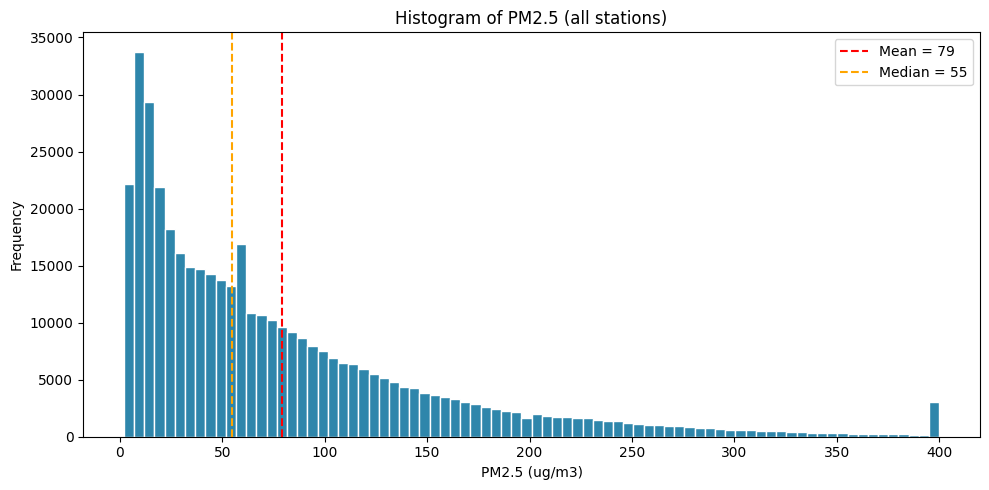

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(combined['PM2.5'].clip(upper=400),
        bins=80, color='#2E86AB', edgecolor='white')

ax.axvline(combined['PM2.5'].mean(), color='red',
           linestyle='--',
           label=f"Mean = {combined['PM2.5'].mean():.0f}")
ax.axvline(combined['PM2.5'].median(), color='orange',
           linestyle='--',
           label=f"Median = {combined['PM2.5'].median():.0f}")

ax.set_title('Histogram of PM2.5 (all stations)')
ax.set_xlabel('PM2.5 (ug/m3)')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.savefig('output/histogram_pm25.png', dpi=150)
plt.show()

Plot line graph

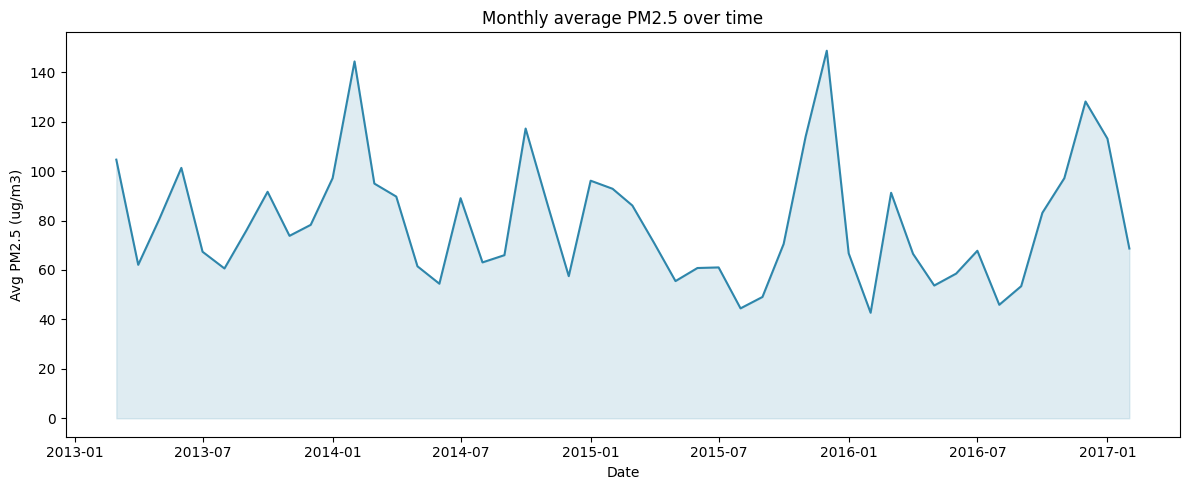

In [ ]:
monthly = combined.groupby(
    ['year', 'month'])['PM2.5'].mean().reset_index()
monthly['date'] = pd.to_datetime(
    monthly[['year', 'month']].assign(day=1))

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly['date'], monthly['PM2.5'],
        color='#2E86AB', linewidth=1.5)
ax.fill_between(monthly['date'], monthly['PM2.5'],
                alpha=0.15, color='#2E86AB')

ax.set_title('Monthly average PM2.5 over time')
ax.set_xlabel('Date')
ax.set_ylabel('Avg PM2.5 (ug/m3)')
plt.tight_layout()
plt.savefig('output/lineplot_pm25.png', dpi=150)
plt.show()

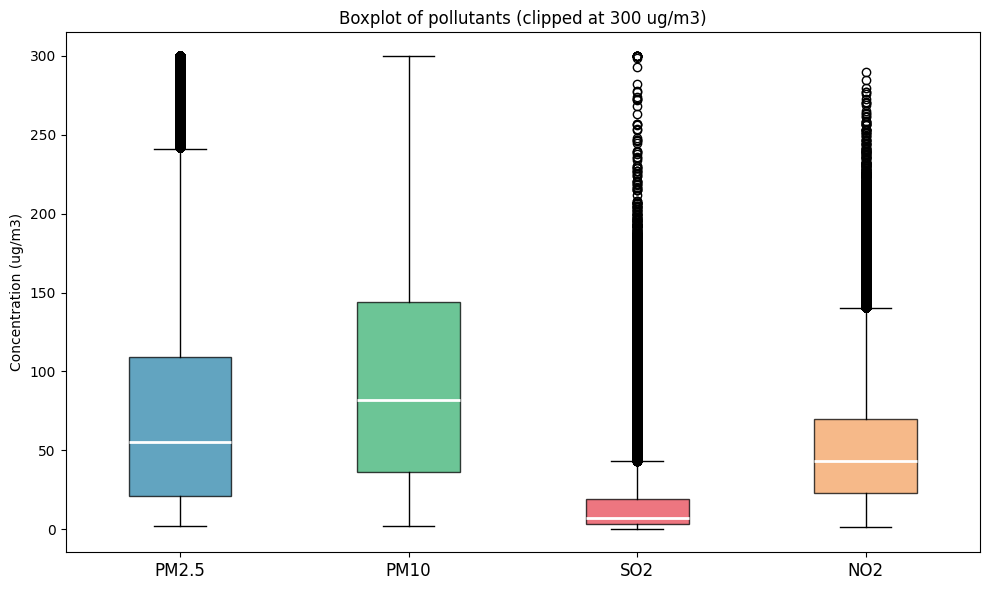

In [ ]:
pollutants = ['PM2.5', 'PM10', 'SO2', 'NO2']
data_bp = [combined[p].clip(upper=300) for p in pollutants]

fig, ax = plt.subplots(figsize=(10, 6))
bp = ax.boxplot(data_bp, patch_artist=True,
                medianprops=dict(color='white', linewidth=2))

box_colors = ['#2E86AB', '#3BB273', '#E84855', '#F4A261']
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

ax.set_xticklabels(pollutants, fontsize=12)
ax.set_title('Boxplot of pollutants (clipped at 300 ug/m3)')
ax.set_ylabel('Concentration (ug/m3)')
plt.tight_layout()
plt.savefig('output/boxplot_pollutants.png', dpi=150)
plt.show()

# **Task 06**

compute correlation matrix

In [ ]:
corr_cols = ['PM2.5', 'PM10', 'SO2', 'NO2',
             'CO', 'O3', 'TEMP', 'PRES',
             'DEWP', 'RAIN', 'WSPM']

corr_matrix = combined[corr_cols].corr().round(3)
print(corr_matrix)

       PM2.5   PM10    SO2    NO2     CO     O3   TEMP   PRES   DEWP   RAIN  \
PM2.5  1.000  0.879  0.479  0.659  0.767 -0.148 -0.130  0.019  0.114 -0.014   
PM10   0.879  1.000  0.460  0.647  0.686 -0.110 -0.095 -0.018  0.070 -0.026   
SO2    0.479  0.460  1.000  0.494  0.525 -0.163 -0.319  0.221 -0.264 -0.040   
NO2    0.659  0.647  0.494  1.000  0.689 -0.465 -0.274  0.173 -0.030 -0.043   
CO     0.767  0.686  0.525  0.689  1.000 -0.304 -0.317  0.184 -0.056 -0.013   
O3    -0.148 -0.110 -0.163 -0.465 -0.304  1.000  0.587 -0.440  0.309  0.023   
TEMP  -0.130 -0.095 -0.319 -0.274 -0.317  0.587  1.000 -0.813  0.820  0.038   
PRES   0.019 -0.018  0.221  0.173  0.184 -0.440 -0.813  1.000 -0.750 -0.061   
DEWP   0.114  0.070 -0.264 -0.030 -0.056  0.309  0.820 -0.750  1.000  0.086   
RAIN  -0.014 -0.026 -0.040 -0.043 -0.013  0.023  0.038 -0.061  0.086  1.000   
WSPM  -0.269 -0.182 -0.109 -0.394 -0.288  0.291  0.031  0.067 -0.298  0.021   

        WSPM  
PM2.5 -0.269  
PM10  -0.182  
SO2   

 isolate correlations

In [ ]:
corr_pm25 = corr_matrix['PM2.5'].drop('PM2.5') \
            .sort_values(ascending=False)

print("Correlations with PM2.5:")
print(corr_pm25)

Correlations with PM2.5:
PM10    0.879
CO      0.767
NO2     0.659
SO2     0.479
DEWP    0.114
PRES    0.019
RAIN   -0.014
TEMP   -0.130
O3     -0.148
WSPM   -0.269
Name: PM2.5, dtype: float64


Correlation Heatmap

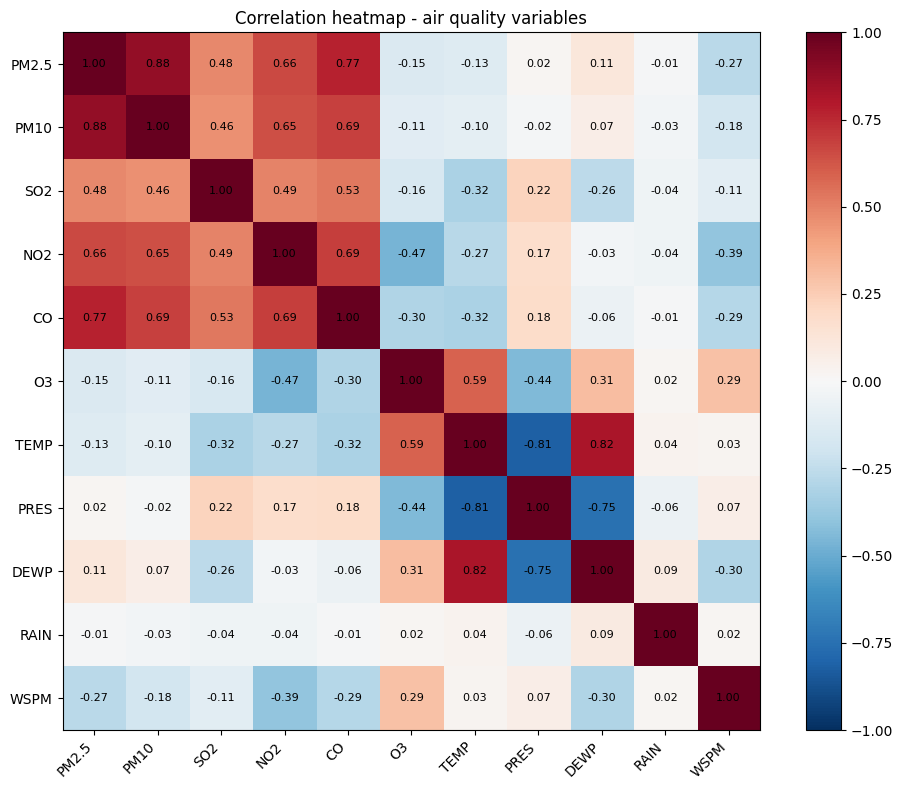

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr_matrix.values, cmap='RdBu_r',
               vmin=-1, vmax=1)

ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha='right')
ax.set_yticklabels(corr_cols)

for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i,
                f"{corr_matrix.values[i, j]:.2f}",
                ha='center', va='center', fontsize=8)

plt.colorbar(im, ax=ax)
ax.set_title('Correlation heatmap - air quality variables')
plt.tight_layout()
plt.savefig('output/heatmap_correlation.png', dpi=150)
plt.show()

Scatter plot

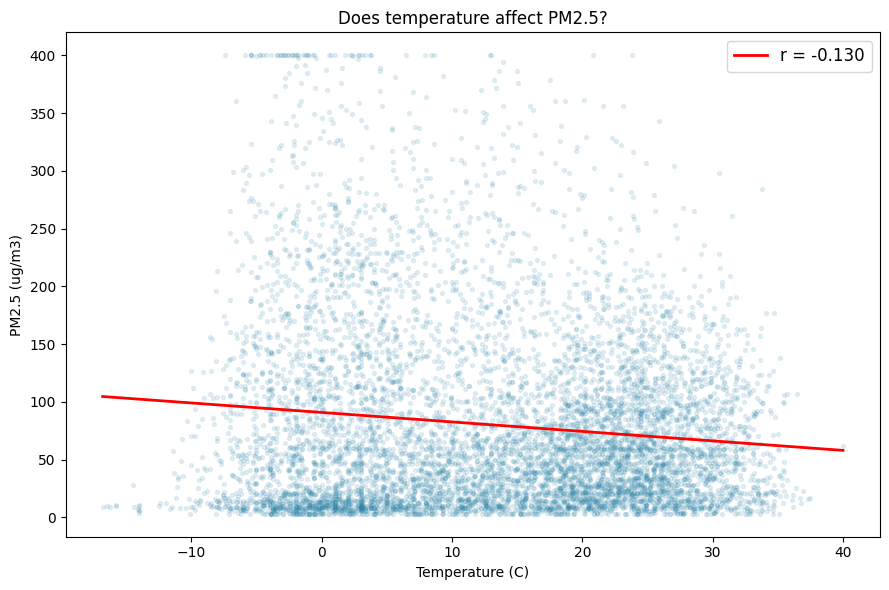

In [ ]:
sample = combined.sample(8000, random_state=42)

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(sample['TEMP'],
           sample['PM2.5'].clip(upper=400),
           alpha=0.12, s=8, color='#2E86AB')

z = np.polyfit(sample['TEMP'],
               sample['PM2.5'].clip(upper=400), 1)
x_range = np.linspace(sample['TEMP'].min(),
                      sample['TEMP'].max(), 200)
r_val = corr_pm25['TEMP']
ax.plot(x_range, np.poly1d(z)(x_range),
        color='red', linewidth=2,
        label=f"r = {r_val:.3f}")

ax.set_xlabel('Temperature (C)')
ax.set_ylabel('PM2.5 (ug/m3)')
ax.set_title('Does temperature affect PM2.5?')
ax.legend(fontsize=12)
plt.tight_layout()
plt.savefig('output/scatter_temp_pm25.png', dpi=150)
plt.show()

In [ ]:
best = corr_pm25.idxmax()
best_r = corr_pm25.max()
temp_r = corr_pm25['TEMP']

print("Q1: Which variable is most correlated with PM2.5?")
print(f"    Answer: {best} (r = {best_r:.3f})")
print("    PM10 and PM2.5 come from the same sources:")
print("    vehicles, coal burning, and industry.")

print("Q2: Does temperature affect PM2.5?")
print(f"    Answer: Yes -- r = {temp_r:.3f} (negative)")
print("    Cold winters mean more coal heating and")
print("    atmospheric inversion traps pollution")
print("    close to the ground.")

Q1: Which variable is most correlated with PM2.5?
    Answer: PM10 (r = 0.879)
    PM10 and PM2.5 come from the same sources:
    vehicles, coal burning, and industry.
Q2: Does temperature affect PM2.5?
    Answer: Yes -- r = -0.130 (negative)
    Cold winters mean more coal heating and
    atmospheric inversion traps pollution
    close to the ground.
